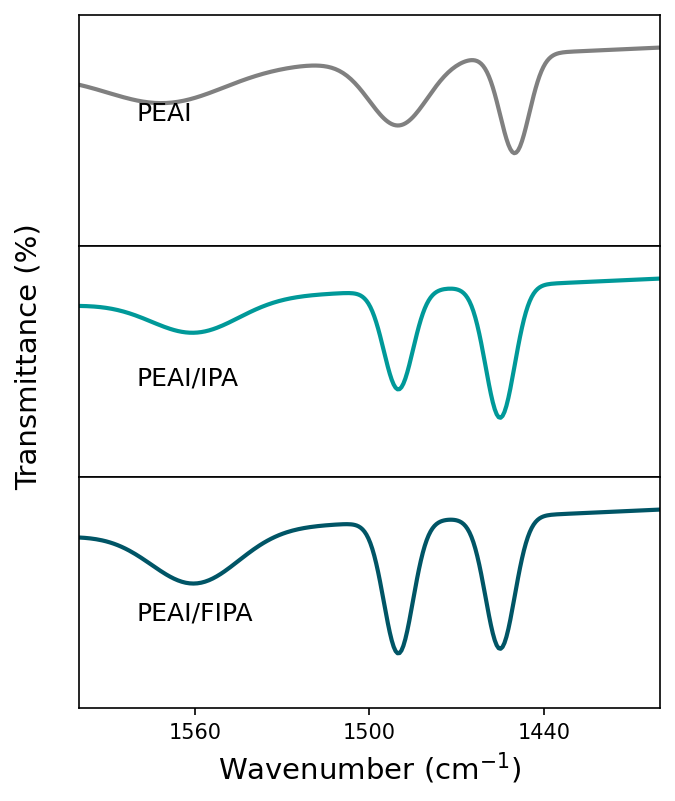

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
wn = np.linspace(1600, 1400, 300)

def dip(x, center, width, depth):
    return -depth * np.exp(-((x - center)**2) / (2 * width**2))

baseline = 100

# 1. PEAI (Grey)
y_peai = baseline + dip(wn, 1450, 5, 15) + dip(wn, 1490, 10, 10) + dip(wn, 1570, 20, 5)
y_peai -= (wn - 1400) * 0.02

# 2. PEAI/IPA (Teal)
y_ipa = baseline + dip(wn, 1455, 5, 20) + dip(wn, 1490, 5, 15) + dip(wn, 1560, 15, 5)
y_ipa -= (wn - 1400) * 0.02

# 3. PEAI/FIPA (Dark Teal)
y_fipa = baseline + dip(wn, 1455, 5, 20) + dip(wn, 1490, 5, 20) + dip(wn, 1560, 15, 8)
y_fipa -= (wn - 1400) * 0.02

# Stack data
# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(5, 6), dpi=150, sharex=True)
plt.subplots_adjust(hspace=0)

datasets = [
    (y_peai, 'gray', 'PEAI'),
    (y_ipa, '#009999', 'PEAI/IPA'),
    (y_fipa, '#005566', 'PEAI/FIPA')
]

for ax, (y, col, lbl) in zip(axes, datasets):
    ax.plot(wn, y, color=col, lw=2)
    ax.text(1580, np.min(y)+5, lbl, fontsize=12)
    
    ax.set_ylim(70, 105)
    ax.set_yticks([]) # Hide Y ticks mostly
    
    if ax != axes[-1]:
        ax.spines['bottom'].set_visible(True)

# X Label
axes[-1].set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=14)
axes[-1].set_xlim(1600, 1400) # Reversed
axes[-1].set_xticks([1560, 1500, 1440])

# Common Y Label
fig.text(0.04, 0.5, 'Transmittance (%)', va='center', rotation='vertical', fontsize=14)

plt.show()
